In [ ]:
# !pip install -q keras==3.11.3

In [ ]:
import os

os.environ["KERAS_BACKEND"] = "torch"

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from imageio.v2 import imread

import keras
from glob import glob
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from utils import CustomEvalDataset

plt.style.use("seaborn-v0_8-notebook")
plt.style.use("petroff10")
plt.set_loglevel("error")

print(f"Keras: {keras.__version__}")
print(f"Numpy: {np.__version__}")

Keras: 3.11.3
Numpy: 2.0.2


In [ ]:
idx_plot = 6
n_epochs = 20
learning_rate = 4e-4

In [ ]:
# This URL has a copy of the dataset, make sure you go to Kaggle though and make an account and follow the license rules.
data_url_zip = "https://github.com/kamalkraj/DATA-SCIENCE-BOWL-2018/blob/master/data/stage1_train.zip?raw=true"
from io import BytesIO
from zipfile import ZipFile
from urllib.request import urlopen

# Download this dataset if we have not already done so
if not os.path.isdir("./data_stage1_train"):
    resp = urlopen(data_url_zip)
    os.mkdir("./data_stage1_train")
    zipfile = ZipFile(BytesIO(resp.read()))
    zipfile.extractall(path="./data_stage1_train")
# Grab all the paths to the images we just unziped
paths = glob("./data_stage1_train/*")

In [ ]:
class DSB2018(Dataset):
    """Dataset class for the 2018 Data Science Bowl."""

    def __init__(self, paths):
        """paths: a list of paths to every image folder in the dataset"""
        self.paths = list(sorted(paths))

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        # There is only one image in each images path. So we will grab the "first" thing we find with "[0]" at the end
        img_path = glob(self.paths[idx] + "/images/*")[0]
        # but there are multiple mask images in each mask path
        mask_imgs = glob(self.paths[idx] + "/masks/*")
        # the image shape is (W, H, 4), the last dimension is an 'alpha' channel that is not used
        img = imread(img_path)[:, :, 0:3]  # trim off the alpha so we get (W, H, 3)
        # Now we want this as (3, W, H), which is the normal shape for PyTorch
        img = np.moveaxis(img, -1, 0)
        # Last step for the image, re-scale it to the range [0, 1]
        img = img / 255.0

        # Every mask image is going to have a shape of (W, H) which has a value of 1 if the pixel
        #  is of a nuclei, and a value of 0 if the image is background/ a  _different_ nuclei
        masks = [imread(f) / 255.0 for f in mask_imgs]

        # Since we want to do simple segmentation, we will create one final mask that
        # contains _all_ nuclei pixels from _every_ mask
        final_mask = np.zeros(masks[0].shape)
        for m in masks:
            final_mask = np.logical_or(final_mask, m)
        final_mask = final_mask.astype(np.float32)

        # Not every image in the dataset is the same size.
        # To simplify the problem, we are going to re-size  every image to be (256, 256)
        img, final_mask = torch.tensor(img), torch.tensor(final_mask).unsqueeze(
            0
        )  # First we convert to PyTorch tensors
        # The interpolate function can be used to re-size a batch of images. So we make each image a "batch" of 1
        img = F.interpolate(img.unsqueeze(0), (256, 256))
        final_mask = F.interpolate(final_mask.unsqueeze(0), (256, 256))
        # Now the shapes  are (B=1, C, W, H) We need to convert them back to FloatTensors
        # and grab the first item in the "batch". This will return a tuple of: (3, 256, 256), (1, 256, 256)
        return img.type(torch.FloatTensor)[0], final_mask.type(torch.FloatTensor)[0]

# Caption: Class for the 2018 data science bowl dataset.
# Each image has a corresponding folder of masks, one for every object in the image.
# We aren’t going to do that kind of object detection yet.
# Instead our DataSet class will go through every mask and “or” them together,
# so that we get a single mask showing every pixel that contains an object.
# This is done inside __getitem__ which will return a tuple with the input image,
# followed by the mask we want to predict (i.e., all pixels that contain nuclei).

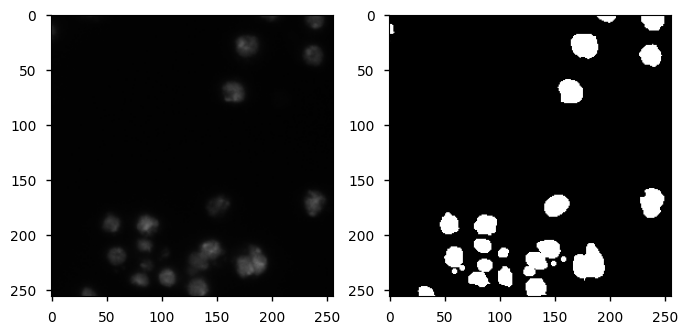

In [ ]:
# Create the Dataset class object
dsb_data = DSB2018(paths)

plt.figure(figsize=(8, 5))
# Plot the original image
plt.subplot(1, 2, 1)
plt.imshow(dsb_data[0][0].permute(1, 2, 0).numpy())
# Plot the mask
plt.subplot(1, 2, 2)
plt.imshow(dsb_data[0][1].numpy()[0, :], cmap="gray")

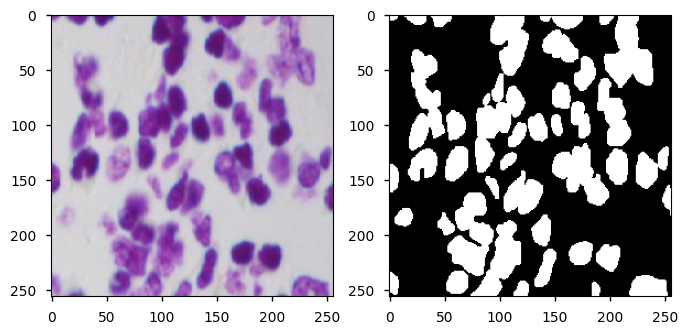

In [ ]:
# Lets plot a second image that is in color
plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
plt.imshow(dsb_data[2][0].permute(1, 2, 0).numpy())
plt.subplot(1, 2, 2)
plt.imshow(dsb_data[2][1].numpy()[0, :], cmap="gray")

In [ ]:
dsb_data[2][0].size()

torch.Size([3, 256, 256])

In [ ]:
train_split, test_split = torch.utils.data.random_split(
    dsb_data, [500, len(dsb_data) - 500]
)
train_seg_loader = DataLoader(train_split, batch_size=16, shuffle=True)
test_seg_loader = DataLoader(test_split, batch_size=16)

In [ ]:
C = 3  # How many channels are in the input?
n_filters = 32  # Smallest value of filters you should usually consider. If we wanted to try and optimize the architecture we could use Optuna to pick a better number of filters.

In [ ]:
# Define our helper function that creates a hidden layer for a CNN
def cnn_layer(out_filters, kernel_size=3):
    """
    in_filters: how many channels are in the input to this layer
    out_filters: how many channels should this layer output
    kernel_size: how large should the filters of this layer be
    """
    conv2d = keras.layers.Conv2D(
        filters=out_filters,
        kernel_size=kernel_size,
        padding="same",
        data_format="channels_first",
    )
    batchnorm = keras.layers.BatchNormalization(axis=1)
    activation = keras.layers.LeakyReLU()
    return keras.layers.Pipeline([conv2d, batchnorm, activation])

In [ ]:
# Specifying a model for image segmentation
segmentation_model_1 = keras.models.Sequential(
    [
        keras.layers.Input(shape=(3, 256, 256)),
        *[cnn_layer(n_filters) for _ in range(6)],  # Create 5 more hidden layers
        # Make a prediction for _every_ location. Notice we use 1 channel out, since we have a binary problem and are using BCEWithLogitsLoss as our loss function.
        keras.layers.Conv2D(
            filters=1,
            kernel_size=3,
            padding="same",
            data_format="channels_first",
            activation="sigmoid",
        ),  # Shape is now (1, W, H)
    ]
)

In [ ]:
segmentation_model_1.compile(
    loss=keras.losses.BinaryCrossentropy(from_logits=False, reduction="mean"),
    optimizer=keras.optimizers.AdamW(learning_rate),
    metrics=[keras.metrics.BinaryCrossentropy(from_logits=False)],
)

callback_1 = CustomEvalDataset(
    datasets=test_seg_loader,
    metrics=keras.metrics.BinaryCrossentropy(from_logits=False),
)

In [ ]:
history_model_1 = segmentation_model_1.fit(
    train_seg_loader, callbacks=[callback_1], epochs=n_epochs
)

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 86s 3s/step - binary_crossentropy: 0.4233 - loss: 0.4233
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - binary_crossentropy: 0.2549 - loss: 0.2549
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - binary_crossentropy: 0.2021 - loss: 0.2021
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - binary_crossentropy: 0.1688 - loss: 0.1688
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - binary_crossentropy: 0.1422 - loss: 0.1422
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - binary_crossentropy: 0.1279 - loss: 0.1279
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - binary_crossentropy: 0.1281 - loss: 0.1281
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - binary_crossentropy: 0.1262 - loss: 0.1262
Epoch 9/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - binary_crossentropy: 0.1217 - loss: 0.1217
Epoch 10/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - binary_crossentropy: 0.1168 - loss: 0.1168
Epoch 11/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/ste

In [ ]:
def plot_segmentation_image(model, index):
    prob = model(test_split[index][0].unsqueeze(0))[0]
    # apply $\sigma$ to the logits to make predictions and then apply a threshold to get a prediction mask
    pred = prob >= 0.5
    # Plot the input, ground truth, and prediction
    plt.figure(figsize=(16, 10))
    plt.subplot(1, 3, 1)
    plt.imshow(
        test_split[index][0].permute(1, 2, 0).numpy(), cmap="gray"
    )  # First plot the original input to the network
    plt.subplot(1, 3, 2)
    plt.imshow(
        test_split[index][1].numpy()[0, :], cmap="gray"
    )  # Second is ground truth
    plt.subplot(1, 3, 3)
    plt.imshow(
        pred[0, :].cpu().numpy(), cmap="gray"
    )  # Third is the prediction our network made

    plt.annotate(
        "Error: Hole",
        color="red",
        fontsize=20,
        xy=(130, 230),
        xycoords="data",
        xytext=(-60, 60),
        textcoords="offset points",
        arrowprops=dict(arrowstyle="->", linewidth=2.5, color="red"),
    )

    plt.annotate(
        "Error: Hole",
        color="red",
        fontsize=20,
        xy=(210, 75),
        xycoords="data",
        xytext=(-160, -60),
        textcoords="offset points",
        arrowprops=dict(arrowstyle="->", linewidth=2.5, color="red"),
    )
    plt.annotate(
        "Error: Phantom object",
        color="red",
        fontsize=20,
        xy=(247, 15),
        xycoords="data",
        xytext=(-240, -50),
        textcoords="offset points",
        arrowprops=dict(arrowstyle="->", linewidth=2.5, color="red"),
    )

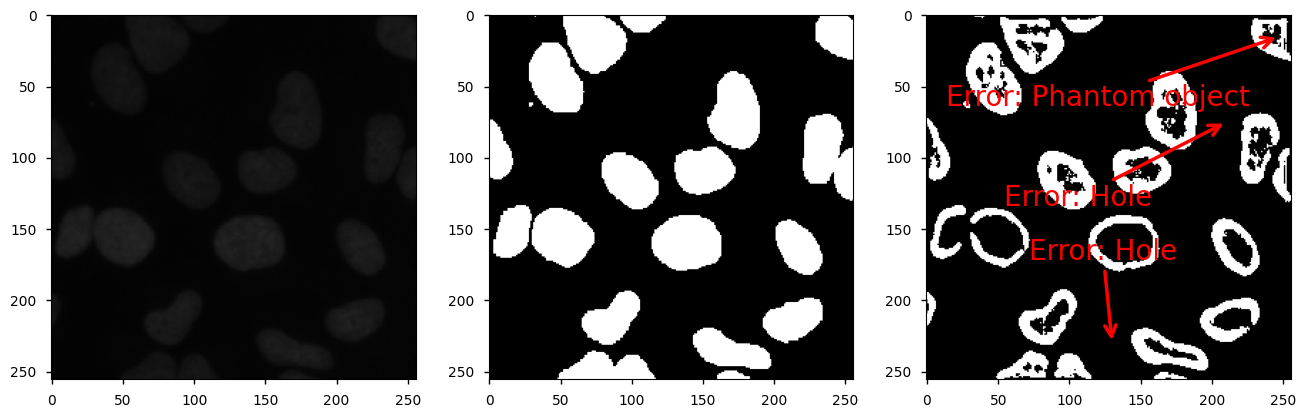

In [ ]:
plot_segmentation_image(segmentation_model_1, idx_plot)

In [ ]:
# Specifying a model for image segmentation
segmentation_model_2 = keras.models.Sequential(
    [
        keras.layers.Input(shape=(3, 256, 256)),
        *[cnn_layer(n_filters) for _ in range(2)],
        keras.layers.MaxPool2D(2, data_format="channels_first"),
        *[cnn_layer(2 * n_filters) for _ in range(3)],
        keras.layers.Conv2DTranspose(
            filters=n_filters,
            kernel_size=3,
            strides=2,
            # output_padding=1,
            padding="same",
            data_format="channels_first",
        ),
        keras.layers.BatchNormalization(axis=1),
        keras.layers.LeakyReLU(),
        # keras.layers.Activation("gelu"),
        cnn_layer(n_filters),
        # Make a prediction for _every_ location. Notice we use 1 channel out, since we have a binary problem and are using BCEWithLogitsLoss as our loss function.
        keras.layers.Conv2D(
            filters=1,
            kernel_size=3,
            padding="same",
            data_format="channels_first",
            activation="sigmoid",
        ),  # Shape is now (1, W, H)
    ]
)

In [ ]:
callback_2 = CustomEvalDataset(
    datasets=test_seg_loader,
    metrics=keras.metrics.BinaryCrossentropy(from_logits=False),
)

segmentation_model_2.compile(
    loss=keras.losses.BinaryCrossentropy(from_logits=False, reduction="mean"),
    optimizer=keras.optimizers.AdamW(learning_rate),
    metrics=[keras.metrics.BinaryCrossentropy(from_logits=False)],
)

In [ ]:
history_model_2 = segmentation_model_2.fit(
    train_seg_loader, callbacks=[callback_2], epochs=n_epochs
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/backend/common/backend_utils.py:91: UserWarning: You might experience inconsistencies across backends when calling conv transpose with kernel_size=3, stride=2, dilation_rate=1, padding=same, output_padding=1.
  warnings.warn(


32/32 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - binary_crossentropy: 0.3789 - loss: 0.3789
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - binary_crossentropy: 0.2116 - loss: 0.2116
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - binary_crossentropy: 0.1682 - loss: 0.1682
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - binary_crossentropy: 0.1403 - loss: 0.1403
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - binary_crossentropy: 0.1251 - loss: 0.1251
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - binary_crossentropy: 0.1154 - loss: 0.1154
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - binary_crossentropy: 0.1061 - loss: 0.1061
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - binary_crossentropy: 0.1045 - loss: 0.1045
Epoch 9/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - binary_crossentropy: 0.0996 - loss: 0.0996
Epoch 10/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - binary_crossentropy: 0.0997 - loss: 0.0997
Epoch 11/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - binary_

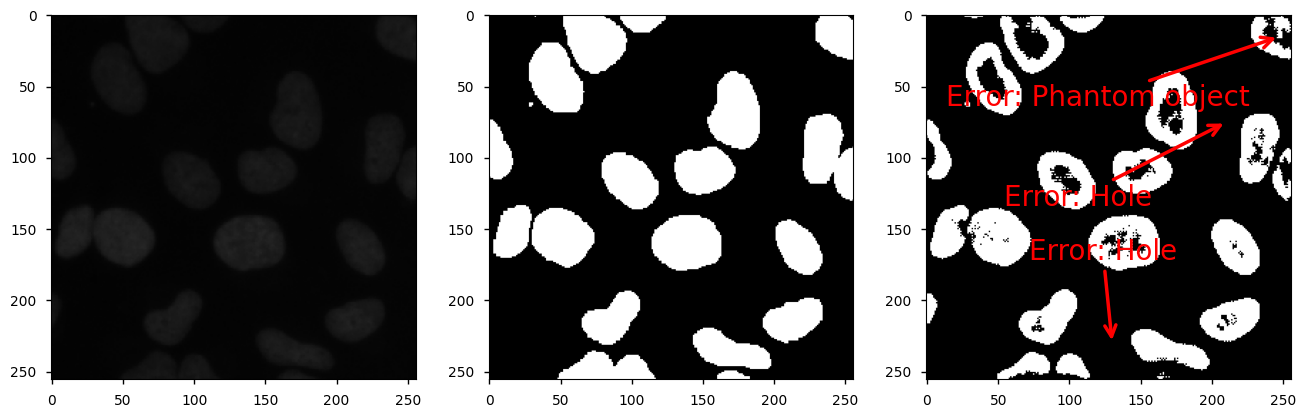

In [ ]:
plot_segmentation_image(segmentation_model_2, idx_plot)

In [ ]:
class UNetBlock2d(keras.layers.Layer):
    def __init__(
            self,
            in_channels,
            mid_channels,
            out_channels=None,
            layers=1,
            sub_network=None,
            filter_size=3,
            **kwargs,
    ):
        super().__init__(**kwargs)

        self.input_layer = None
        self.bottleneck = None
        self.output_layer = None
        self.mid_channels = mid_channels
        self.out_channels = out_channels
        self.num_layers = layers
        self.filter_size = filter_size
        self.sub_network = sub_network

        # Determine if we need to double channels for concatenation
        if sub_network is None:
            self.inputs_to_outputs = 1
        else:
            self.inputs_to_outputs = 2

    def build(self, input_shape):
        # Build input layers
        self.input_layer = keras.layers.Pipeline(
            [
                cnn_layer(self.mid_channels, self.filter_size)
                for _ in range(self.num_layers)
            ]
        )

        output_layer: list[keras.layers.Layer] = [
            cnn_layer(self.mid_channels, self.filter_size)
            for _ in range(self.num_layers)
        ]

        if self.out_channels is not None:
            l = keras.layers.Conv2D(
                self.out_channels, 1, padding="same", data_format="channels_first"
            )
            output_layer.append(l)

        self.output_layer = keras.layers.Pipeline(output_layer)

        # Build bottleneck if sub_network provided
        if self.sub_network is not None:
            self.bottleneck = keras.layers.Pipeline(
                [
                    keras.layers.MaxPooling2D(
                        pool_size=2, data_format="channels_first"
                    ),
                    self.sub_network,
                    keras.layers.Conv2DTranspose(
                        self.mid_channels,
                        self.filter_size,
                        strides=2,
                        data_format="channels_first",
                        padding="same",
                    ),
                ]
            )
        else:
            self.bottleneck = None

    def call(self, inputs, training=None):
        x = inputs
        full_scale_result = self.input_layer(x)  # (B, C, W, H)
        # check if we have a bottleneck to apply
        if self.bottleneck is not None:
            # (B, C, W, H) shape because bottleneck does both the pooling & expansion
            bottle_result = self.bottleneck(full_scale_result)
            # Now shape (B, 2*C, W, H)
            full_scale_result = keras.ops.concatenate(
                [full_scale_result, bottle_result], axis=1
            )
        # compute the output on the concatenated (or not!) result
        return self.output_layer(full_scale_result)

In [ ]:
unet_model = keras.models.Sequential(
    [
        keras.layers.Input(shape=(3, 256, 256)),
        UNetBlock2d(
            3,
            32,
            layers=2,
            sub_network=UNetBlock2d(
                32,
                64,
                out_channels=32,
                layers=2,
                sub_network=UNetBlock2d(64, 128, out_channels=64, layers=2),
            ),
        ),
        # Prediction for _every_ location
        keras.layers.Conv2D(
            1, 1, data_format="channels_first", padding="same", activation="sigmoid"
        ),
        # Shape is now (B, 1, W, H)
    ]
)

In [ ]:
unet_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ u_net_block2d_2 (UNetBlock2d)   │ (None, 32, 256, 256)   │       780,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 1, 256, 256)    │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 780,737 (2.98 MB)

 Trainable params: 778,945 (2.97 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [ ]:
callback_unet = CustomEvalDataset(
    datasets=test_seg_loader,
    metrics=keras.metrics.BinaryCrossentropy(from_logits=False),
)

unet_model.compile(
    loss=keras.losses.BinaryCrossentropy(from_logits=False, reduction="mean"),
    optimizer=keras.optimizers.AdamW(learning_rate),
    metrics=[keras.metrics.BinaryCrossentropy(from_logits=False)],
)

In [ ]:
history_unet = unet_model.fit(train_seg_loader, callbacks=[callback_unet], epochs=n_epochs)

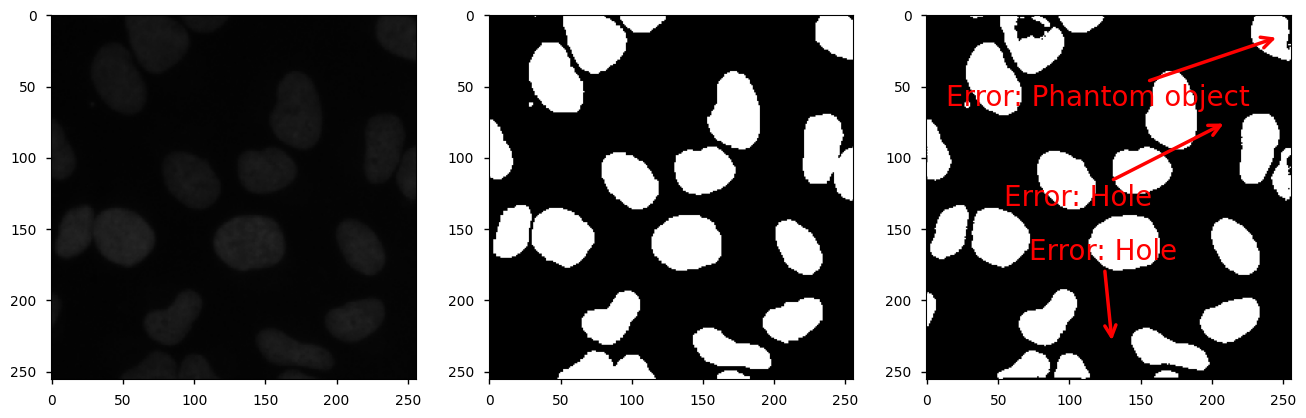

In [ ]:
plot_segmentation_image(unet_model, idx_plot)

In [ ]:
pd.DataFrame(
    {
        "epochs": range(len(callback_1.list_metrics)),
        "test_loss_model_1": callback_1.list_metrics,
        "test_loss_model_2": callback_2.list_metrics,
        "test_loss_unet": callback_unet.list_metrics,
    }
).set_index("epochs").plot()